# 15 · CCF e EAD — a conversão do limite não sacado

Em produto **rotativo** (cartão, cheque especial, capital de giro com limite) a exposição
no *default* **não é conhecida**: o cliente decide quanto saca, e quem está indo para o
*default* costuma sacar mais. O parâmetro que fecha essa conta é o **CCF**:

$$EAD = sacado_{ref} + CCF \cdot (limite_{ref} - sacado_{ref})$$

O `CCF` (*credit conversion factor*, também chamado **LEQ**, *loan equivalent*) é a fração
do **não sacado** que vira exposição.

E aqui vale o aviso que organiza o tutorial inteiro: **o que mais move o número não é o
modelo — é o desenho da base**. De qual data de referência se olha o contrato muda o CCF
médio por um fator de duas vezes ou mais. Por isso o desenho tem de ser documentado junto
do número.

Roteiro:

1. o problema do rotativo
2. **os três desenhos** de base de referência, e por que divergem
3. as **quatro medidas ex-post** e a identidade que as liga
4. **higiene do dado** — o que faz o CCF explodir se ignorado
5. a distribuição é **bimodal**, e isso decide o estimador
6. estimação agrupada e *downturn*
7. **backtest de EAD** — o teste que decide se o parâmetro serve
8. monitoramento (PSI entre safras)
9. a ponte com o **`ModelSegmenter`** para o modelo preditivo
10. registro no MLflow

| tutoriais irmãos | |
|---|---|
| [`12`](12_tutorial_ecl.ipynb) | a perda esperada **ponta a ponta** |
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** — quando o risco se materializa |
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** — a perda dos contratos já em *default* |

> Metodologia e referências (Moral 2011; Tong, Mues, Brown & Thomas 2016; Gürtler, Hibbeln
> & Usselmann 2018): [`docs/credit-risk/ecl.md`](../../docs/credit-risk/ecl.md).

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))

In [2]:
%matplotlib inline
import os
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

---
## 1 · O problema: a exposição não é conhecida

Num empréstimo com prazo definido, a exposição futura é uma conta de amortização. Num
rotativo, ela depende do **comportamento**: o cliente pode ficar parado, ir consumindo o
limite aos poucos, ou estourar tudo às vésperas de quebrar.

Geramos um painel com três perfis de saque explícitos — é essa mistura que produz a
distribuição bimodal característica do CCF, e é ela que o resto do tutorial dissseca.

In [3]:
def painel_rotativo(n=900, meses=34, seed=9):
    '''Painel de contratos rotativos com DGP conhecido.

    Três perfis de saque: `inerte` (não mexe no limite -> CCF ~ 0), `gradual` e
    `agressivo` (vai ao limite perto do default -> CCF ~ 1). A intensidade sobe com a
    PROXIMIDADE do default, que é o fenômeno que o CCF mede.
    '''
    rng = np.random.default_rng(seed)
    linhas = []
    for i in range(n):
        segmento = "cartao" if rng.uniform() < 0.6 else "cheque_especial"
        limite = float(rng.lognormal(8.5, 0.5))
        sacado = limite * float(rng.beta(2.0, 3.0))
        perfil = str(rng.choice(["inerte", "gradual", "agressivo"], p=[0.30, 0.45, 0.25]))
        intensidade = {"inerte": 0.0, "gradual": 0.12, "agressivo": 0.9}[perfil]
        comportamento = float(rng.normal(
            {"inerte": -1.2, "gradual": 0.0, "agressivo": 1.2}[perfil], 0.4))
        quebra = int(rng.integers(14, meses)) if rng.uniform() < 0.45 else None
        for t in range(meses):
            data = pd.Timestamp("2021-01-01") + pd.DateOffset(months=t)
            if quebra is not None and t >= quebra:
                linhas.append((f"F{i:04d}", data, sacado, limite, 1, segmento,
                               comportamento, perfil))
                break
            proximidade = 0.0 if quebra is None else max(0.0, 1 - (quebra - t) / 12)
            passo = intensidade * proximidade * rng.uniform(0.4, 1.6)
            sacado = float(np.clip(sacado + (limite - sacado) * np.clip(passo, 0, 1)
                                   + limite * rng.normal(0, 0.008), 0, limite))
            linhas.append((f"F{i:04d}", data, sacado, limite, 0, segmento,
                           comportamento, perfil))
    return pd.DataFrame(linhas, columns=[
        "id_contrato", "dt_ref", "sacado", "limite", "default", "segmento",
        "feat_comportamento", "perfil"])

df = painel_rotativo()
df["safra"] = df["dt_ref"].dt.year
n_def = int(df.groupby("id_contrato")["default"].max().sum())
print(f"{df['id_contrato'].nunique()} contratos, {len(df)} observações, {n_def} defaults")
df.head(3)

900 contratos, 26610 observações, 408 defaults


,id_contrato,dt_ref,sacado,limite,default,segmento,feat_comportamento,perfil,safra
0,F0000,2021-01-01,388.781015,5549.28824,0,cheque_especial,1.300373,agressivo,2021
1,F0000,2021-02-01,500.757990,5549.28824,0,cheque_especial,1.300373,agressivo,2021
2,F0000,2021-03-01,513.089863,5549.28824,0,cheque_especial,1.300373,agressivo,2021


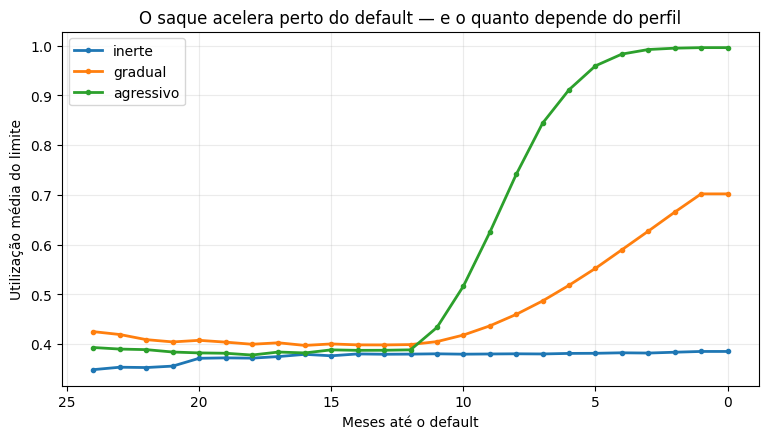

In [4]:
# A utilização do limite sobe conforme o default se aproxima — é isso que o CCF captura.
quebrados = df[df.groupby("id_contrato")["default"].transform("max") == 1].copy()
quebra_em = quebrados[quebrados["default"] == 1].set_index("id_contrato")["dt_ref"]
quebrados["meses_ate_quebra"] = (
    pd.PeriodIndex(quebrados["id_contrato"].map(quebra_em), freq="M").asi8
    - pd.PeriodIndex(quebrados["dt_ref"], freq="M").asi8)
uso = (quebrados[quebrados["meses_ate_quebra"].between(0, 24)]
       .assign(utilizacao=lambda d: d["sacado"] / d["limite"])
       .groupby(["perfil", "meses_ate_quebra"])["utilizacao"].mean().unstack(0))

fig, ax = plt.subplots(figsize=(9, 4.6))
for perfil in ["inerte", "gradual", "agressivo"]:
    ax.plot(uso.index, uso[perfil], lw=2, marker="o", ms=3, label=perfil)
ax.invert_xaxis()
ax.set_xlabel("Meses até o default"); ax.set_ylabel("Utilização média do limite")
ax.set_title("O saque acelera perto do default — e o quanto depende do perfil")
ax.grid(alpha=.25); ax.legend()
plt.show()

---
## 2 · Os três desenhos de base de referência

O CCF observado é `(EAD − sacado_ref) / (limite_ref − sacado_ref)`. Note o subscrito: tudo
depende de **onde fica a data de referência**.

| `method` | data de referência | tempo até o *default* |
|---|---|---|
| `"cohort"` | grade de calendário espaçada de `horizon` | varia de 0 a `horizon − 1` |
| `"fixed_horizon"` | exatamente `horizon` períodos antes | sempre `horizon` |
| `"variable"` | **todas** as datas em `[default − horizon, default)` | 1 a `horizon` |

In [5]:
from yggdrasil.credit_risk.ecl import reference_dataset

bases = {m: reference_dataset(df, method=m, horizon=12, segment_col="segmento",
                              extra_cols=["feat_comportamento", "perfil", "safra"])
         for m in ("cohort", "fixed_horizon", "variable")}

pd.DataFrame({m: {"n observações": len(b),
                  "n contratos": int(b.frame["id"].nunique()),
                  "meses até o default (média)": b.frame["meses_ate_default"].mean(),
                  "CCF médio": float(b.values.mean()),
                  "CCF mediano": float(b.values.median())}
              for m, b in bases.items()}).T.round(3)

,n observações,n contratos,meses até o default (média),CCF médio,CCF mediano
cohort,384.0,384.0,6.104,0.364,0.303
fixed_horizon,408.0,408.0,12.000,0.478,0.497
variable,4782.0,408.0,6.605,0.357,0.316


A divergência não é ruído: **quanto mais cedo a data de referência, mais tempo o cliente
teve para sacar — e maior o CCF**. O `fixed_horizon` olha sempre 12 meses antes e captura a
conversão inteira; a `cohort` olha, em média, bem mais perto do evento e captura só o que
ainda restava converter.

Usar um número estimado com um desenho e aplicá-lo como se fosse do outro é um erro de
calibração silencioso — e é por isso que o desenho vai na documentação junto do número.

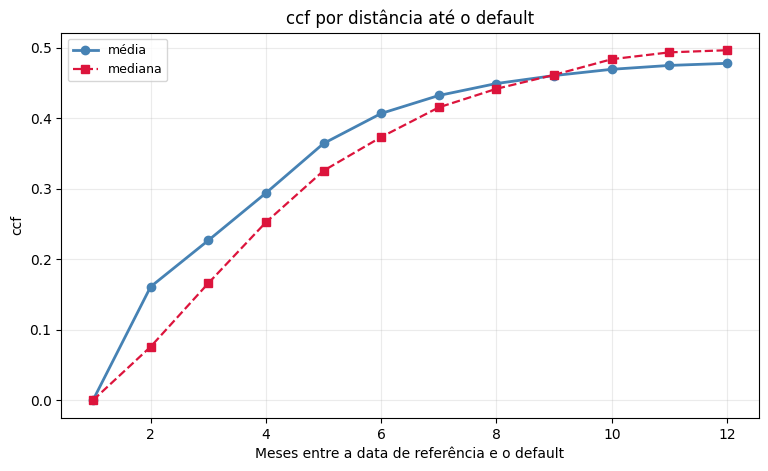

In [6]:
# Com method='variable' dá para ver a conversão acontecendo mês a mês.
from yggdrasil.credit_risk.ecl import report

fig = report.plot_ccf_by_horizon(bases["variable"])

> **Sobre a coorte generalizada.** A "coorte generalizada" de Gürtler, Hibbeln & Usselmann
> (2018) — coortes sobrepostas começando em todo período, em vez da grade fixa de
> calendário — produz **exatamente o mesmo conjunto** de pares (contrato, data de
> referência) que `"variable"` quando a amostra é a dos **inadimplentes**. A generalização
> daquele artigo está no conjunto em risco dos **adimplentes**, que não entra na estimação
> do CCF. Por isso o pacote expõe três desenhos, e não quatro: um quarto nome para a mesma
> coisa seria falsa completude.

---
## 3 · As quatro medidas ex-post

A mesma exposição realizada pode ser resumida de quatro formas. Todas são
**reparametrizações da mesma observação** — e é essa identidade que permite compará-las no
mesmo *backtest*.

| medida | definição | reconstrução do EAD |
|---|---|---|
| `ccf` (LEQ) | `(EAD − sacado) / (limite − sacado)` | `sacado + CCF·(limite − sacado)` |
| `eadf` | `EAD / limite` | `EADF · limite` |
| `auf` | `(EAD − sacado) / limite` | `sacado + AUF · limite` |
| `ead` | o próprio EAD | `EAD` |

In [7]:
from yggdrasil.credit_risk.ecl import ead_from_measure, MEASURES

base = reference_dataset(df, method="fixed_horizon", segment_col="segmento",
                         extra_cols=["feat_comportamento", "perfil", "safra"], clip=False)
f = base.frame
for medida in MEASURES:
    reconstruido = ead_from_measure(f["sacado_ref"], f["limite_ref"], f[medida], measure=medida)
    print(f"{medida:5s} reconstrói o EAD realizado: "
          f"{np.allclose(reconstruido, f['ead'], atol=1e-6)}")
f[["sacado_ref", "limite_ref", "ead", "ccf", "eadf", "auf"]].head(4).round(3)

ccf   reconstrói o EAD realizado: True
eadf  reconstrói o EAD realizado: True
auf   reconstrói o EAD realizado: True
ead   reconstrói o EAD realizado: True


,sacado_ref,limite_ref,ead,ccf,eadf,auf
0,610.028,5549.288,5537.767,0.998,0.998,0.888
1,2586.275,6535.048,2561.035,-0.006,0.392,-0.004
2,2732.307,9707.750,6309.886,0.513,0.650,0.369
3,1658.722,9402.675,5173.150,0.454,0.550,0.374


### Por que o `ccf` é o mais instável

O denominador do CCF é o **não sacado**. Quando o cliente já está quase no limite,
`limite − sacado` tende a zero e o fator **explode** — uma variação pequena em moeda vira
uma variação enorme no fator. `eadf` e `auf` trocam esse denominador pelo limite, que é
estável.

In [8]:
faixas = pd.cut(f["utilizacao_ref"], [0, .5, .8, .95, 1.0],
                labels=["até 50%", "50–80%", "80–95%", "95–100%"])
pd.DataFrame({
    "n": f.groupby(faixas, observed=True).size(),
    "CCF — desvio": f.groupby(faixas, observed=True)["ccf"].std(),
    "EADF — desvio": f.groupby(faixas, observed=True)["eadf"].std(),
    "AUF — desvio": f.groupby(faixas, observed=True)["auf"].std(),
}).round(3)

,n,CCF — desvio,EADF — desvio,AUF — desvio
utilizacao_ref,,,,
até 50%,280,0.373,0.285,0.272
50–80%,116,0.349,0.141,0.146
80–95%,11,0.373,0.045,0.047


A evidência empírica da literatura ainda assim favorece o `ccf` para **acurácia de
estimação** — mas isso é resultado empírico, não teorema, e depende da carteira. Por isso o
pacote traz `compare_measures`, que roda as quatro no mesmo *backtest* (seção 7).

---
## 4 · Higiene do dado

Quatro coisas quebram uma base de CCF, e todas são silenciosas se não forem tratadas:

| problema | por quê | tratamento |
|---|---|---|
| limite zero ou nulo | divisão por zero em `eadf`/`auf` | `min_limit` |
| **não sacado zero** | divisão por zero no `ccf`; a observação **não informa nada** sobre conversão | `min_undrawn` |
| sacado **acima** do limite | não sacado negativo, CCF com sinal invertido | `drop_over_limit` |
| referência **já em *default*** | o "limite disponível" já não é disponível | automático |

E o mais importante: cada exclusão é **contada**, não silenciosa.

In [9]:
# Injetamos problemas reais para ver os filtros trabalhando.
sujo = df.copy()
sujo.loc[sujo.index[:400], "limite"] = 0.0                                   # limite zerado
alvo = sujo.index[400:900]
sujo.loc[alvo, "sacado"] = sujo.loc[alvo, "limite"] * 1.15                   # excesso autorizado

b_sujo = reference_dataset(sujo, method="variable", drop_over_limit=True)
b_sujo.excluded_frame().round(4)

,motivo,n,pct
0,sacado_acima_do_limite,120,0.0245
1,nao_sacado_abaixo_do_piso,108,0.0221
2,limite_abaixo_do_piso,48,0.0098
3,sem_observacao_na_referencia,0,0.0000
4,ja_em_default_na_referencia,0,0.0000
5,saldo_nao_numerico,0,0.0000


In [10]:
print("depois dos filtros:")
print(f"  limite sempre > 0 ......: {(b_sujo.frame['limite_ref'] > 0).all()}")
print(f"  não sacado sempre > 0 ..: {(b_sujo.frame['nao_sacado_ref'] > 0).all()}")
print(f"  nenhum over-limit ......: {not b_sujo.frame['over_limit_ref'].any()}")

depois dos filtros:
  limite sempre > 0 ......: True
  não sacado sempre > 0 ..: True
  nenhum over-limit ......: True


### O que acontece sem o filtro de *over limit*

Quando o sacado excede o limite, o não sacado fica **negativo** e o CCF muda de sinal — um
saque adicional passa a produzir um fator negativo. O resultado é uma cauda absurda que
contamina a média.

In [11]:
sem_filtro = reference_dataset(sujo, method="variable", drop_over_limit=False,
                               min_undrawn=-1e12, clip=False)
com_filtro = reference_dataset(sujo, method="variable", drop_over_limit=True, clip=False)
pd.DataFrame({
    "sem filtrar over-limit": sem_filtro.values.describe(),
    "com filtro (padrão)": com_filtro.values.describe(),
}).round(3)

C:\Users\Heage\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sem filtrar over-limit,com filtro (padrão)
count,4772.000,4620.000
mean,-inf,0.317
std,NaN,0.727
min,-inf,-20.693
25%,0.006,0.012
50%,0.286,0.309
75%,0.509,0.516
max,1.000,1.000


### Recorte e winsorização

O CCF cru pode passar de 1 (saque acima do disponível, encargos capitalizados) ou ficar
negativo (o contrato amortizou antes de quebrar). O recorte em `[0, 1]` é a convenção
usual; a base guarda a versão crua em `ccf_bruto` e marca em `recortado` **o que foi
tocado**.

In [12]:
cru = reference_dataset(df, method="variable", clip=False)
recortado = reference_dataset(df, method="variable", clip=True)
wins = reference_dataset(df, method="variable", clip=False, winsorize=0.02)

pd.DataFrame({
    "cru": {"mín": cru.values.min(), "máx": cru.values.max(), "média": cru.values.mean()},
    "recortado [0,1]": {"mín": recortado.values.min(), "máx": recortado.values.max(),
                        "média": recortado.values.mean()},
    "winsorizado 2%": {"mín": wins.values.min(), "máx": wins.values.max(),
                       "média": wins.values.mean()},
}).T.round(4)

,mín,máx,média
cru,-20.6929,1.0,0.3211
"recortado [0,1]",0.0000,1.0,0.3568
winsorizado 2%,-0.0536,1.0,0.3539


In [13]:
print(f"observações recortadas: {int(recortado.frame['recortado'].sum())} "
      f"de {len(recortado)} ({recortado.frame['recortado'].mean():.1%})")

observações recortadas: 591 de 4782 (12.4%)


---
## 5 · A distribuição é **bimodal** — e isso decide o estimador

O CCF observado não se distribui em torno de uma média: ele se concentra em **0** (o
cliente não mexeu no limite) e em **1** (sacou tudo), com massa achatada no meio. Ajustar
uma média a isso esconde mais do que revela.

In [14]:
base_var = bases["variable"]
base_var.distribution(bins=10).round(4)

,faixa,n,pct
0,= 0,955,0.1997
1,"(0.00, 0.10]",884,0.1849
2,"(0.10, 0.20]",229,0.0479
3,"(0.20, 0.30]",267,0.0558
4,"(0.30, 0.40]",417,0.0872
5,"(0.40, 0.50]",720,0.1506
6,"(0.50, 0.60]",364,0.0761
7,"(0.60, 0.70]",36,0.0075
8,"(0.70, 0.80]",35,0.0073
9,"(0.80, 0.90]",56,0.0117


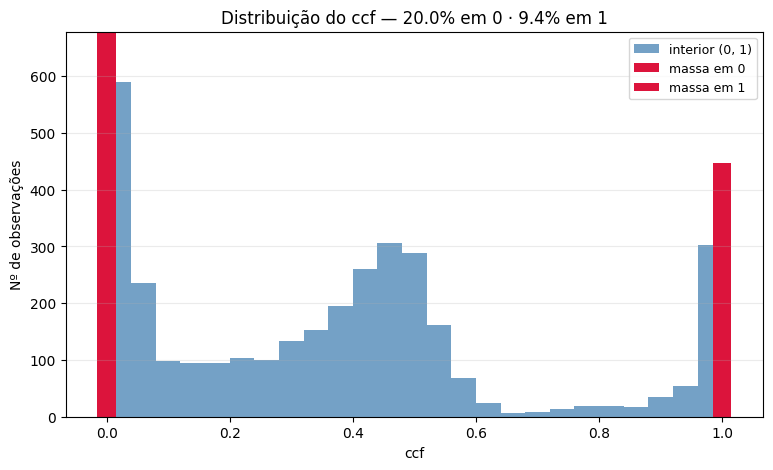

In [15]:
fig = base_var.plot()

In [16]:
# E a bimodalidade tem NOME: são os perfis de saque do DGP.
pd.crosstab(base.frame["perfil"],
            pd.cut(base.frame["ccf"], [-0.01, 0.05, 0.95, 1.01],
                   labels=["≈ 0", "meio", "≈ 1"]),
            normalize="index").round(3)

ccf,≈ 0,meio,≈ 1
perfil,,,
agressivo,0.000,0.020,0.98
gradual,0.000,1.000,0.00
inerte,0.627,0.373,0.00


Na carteira real esses perfis não vêm rotulados — mas existem, e é isso que a bimodalidade
está dizendo. A implicação prática: **a média agrupada descreve mal a carteira**, e um
modelo com covariáveis (seção 9) tende a valer o custo, porque o que ele faz é justamente
separar os perfis.

---
## 6 · Estimação agrupada e *downturn*

Três estatísticas, três perguntas diferentes:

- **`mean`** — trata cada contrato como uma observação;
- **`median`** — robusta à cauda, mas ignora a massa em 1;
- **`weighted`** — ponderada pelo **denominador natural** da medida (o não sacado, para o
  CCF). É a que **preserva a soma do EAD da carteira**, e por isso a que costuma passar no
  *backtest* em moeda.

In [17]:
from yggdrasil.credit_risk.ecl import pooled_ccf

comparacao = pd.concat([pooled_ccf(base, by="segmento", stat=s) for s in
                        ("mean", "median", "weighted")], ignore_index=True)
comparacao[["estatistica", "grupo", "n", "ccf", "ic_inf", "ic_sup",
            "massa_em_0", "massa_em_1"]].round(4)

,estatistica,grupo,n,ccf,ic_inf,ic_sup,massa_em_0,massa_em_1
0,mean,cartao,250,0.4688,0.4223,0.5153,0.1400,0.1040
1,mean,cheque_especial,158,0.4793,0.4248,0.5337,0.1076,0.1139
2,median,cartao,250,0.4944,0.4478,0.5409,0.1400,0.1040
3,median,cheque_especial,158,0.5024,0.4480,0.5568,0.1076,0.1139
4,weighted,cartao,250,0.4469,0.4003,0.4934,0.1400,0.1040
5,weighted,cheque_especial,158,0.4913,0.4369,0.5457,0.1076,0.1139


In [18]:
# CCF downturn: quantil alto da distribuição, para o capital (não para a provisão).
# Reexportado de capital.parameters — fonte única no repositório.
from yggdrasil.credit_risk.ecl import ccf_downturn

pd.DataFrame([{"quantil": q, "CCF downturn": base.downturn(q)}
              for q in (0.5, 0.75, 0.90, 0.95, 0.99)]).round(4)

,quantil,CCF downturn
0,0.50,0.4967
1,0.75,0.6172
2,0.90,1.0000
3,0.95,1.0000
4,0.99,1.0000


---
## 7 · Backtest de EAD — o teste que decide

Estimativa de CCF não se valida olhando o CCF: valida-se **reconstruindo o EAD** e
comparando com o realizado. E o número que importa é o **viés em moeda** — um CCF com erro
médio zero por contrato pode subestimar a carteira inteira se errar justamente nos
contratos grandes.

In [19]:
from yggdrasil.credit_risk.ecl import backtest_ead

estimativas = {k: float(v) for k, v in
               zip(*pooled_ccf(base, by="segmento", stat="weighted")[["grupo", "ccf"]].to_numpy().T)}
backtest_ead(base, estimativas, by="segmento").round(4)

,grupo,n,ead_previsto,ead_realizado,vies,vies_relativo,erro_medio,mae,rmse,erro_absoluto_relativo,medida
0,__global__,408,1.550787e+06,1.550787e+06,0.0,0.0,0.0,971.2375,1462.6625,0.2555,ccf
1,cartao,250,9.305484e+05,9.305484e+05,0.0,0.0,-0.0,1007.7153,1496.4834,0.2707,ccf
2,cheque_especial,158,6.202390e+05,6.202390e+05,0.0,0.0,0.0,913.5193,1407.4891,0.2327,ccf


In [20]:
# Viés injetado é detectado — nos dois sentidos.
pd.DataFrame([
    {"CCF aplicado": rotulo, **backtest_ead(base, valor).iloc[0][
        ["ead_previsto", "ead_realizado", "vies", "vies_relativo", "rmse"]].to_dict()}
    for rotulo, valor in [("0,0 (ignora conversão)", 0.0),
                          ("estimado (ponderado)", float(pooled_ccf(base, stat='weighted')['ccf'].iloc[0])),
                          ("1,0 (converte tudo)", 1.0)]
]).round(4)

,CCF aplicado,ead_previsto,ead_realizado,vies,vies_relativo,rmse
0,"0,0 (ignora conversão)",8.846611e+05,1.550787e+06,-666126.2871,-0.4295,2440.4728
1,estimado (ponderado),1.550787e+06,1.550787e+06,-0.0000,-0.0000,1475.0959
2,"1,0 (converte tudo)",2.320165e+06,1.550787e+06,769377.8672,0.4961,2835.3718


In [21]:
# As quatro medidas no MESMO backtest — a comparação que a validação vai pedir.
from yggdrasil.credit_risk.ecl import compare_measures

compare_measures(base)[["medida", "vies_relativo", "erro_absoluto_relativo",
                        "mae", "rmse"]].round(5)

,medida,vies_relativo,erro_absoluto_relativo,mae,rmse
0,ccf,0.00815,0.25380,964.69914,1477.71772
1,auf,-0.00064,0.29968,1139.08497,1559.28031
2,eadf,0.01300,0.31374,1192.50623,1747.95219
3,ead,0.00000,0.54567,2074.05942,2787.12313


---
## 8 · Monitoramento: PSI entre safras

Se a distribuição do CCF muda, a estimativa em produção envelheceu. O PSI usa as faixas do
grupo de referência e a fórmula única do repositório
(`credit_risk._common.psi_from_shares`), com os mesmos limiares de classificação dos
segmentadores.

In [22]:
from yggdrasil.credit_risk.ecl import ccf_psi

ccf_psi(bases["variable"], by="safra").round(4)

,grupo,n,psi,classificacao,media,referencia
0,2023,853,0.0000,estável,0.2402,True
1,2022,2722,0.2124,atenção,0.3496,False
2,2021,1207,0.8585,instável,0.4556,False


---
## 9 · A ponte com o `ModelSegmenter` — o modelo preditivo

O módulo de CCF **não** reimplementa motor de regressão, e isso é decisão de projeto: o CCF
é um alvo contínuo em `[0, 1]`, exatamente o caso do
`ModelSegmenter(task_type="regression")` que o pacote já tem — com seleção de variáveis,
SHAP, ratings, tuning e persistência.

A base que sai de `reference_dataset` **já está no formato** que ele consome.

In [23]:
from yggdrasil.credit_risk.model import ModelSegmenter

modelo_base = base.frame.copy()
seg = ModelSegmenter(
    modelo_base, target="ccf", task_type="regression",
    features=["feat_comportamento", "utilizacao_ref", "limite_ref"],
    problem_label="CCF",
    score_scale=1.0,        # o "score" É o CCF previsto (sem reescalar para 0–1000)
    verbose=False,
)
seg.fit("lightgbm")
seg.metrics().round(4)

C:\Users\Heage\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,amostra,n,rmse,mae,mape,smape,medae,r2,mean_bias
0,DES,408,0.0765,0.0509,44.2905,37.4669,0.0298,0.956,0.0


In [24]:
modelo_base["ccf_previsto"] = seg.predict(
    modelo_base, col_score="ccf_previsto")["ccf_previsto"].to_numpy()

# Um regressor contínuo pode sair de [0, 1] — o alvo é limitado, o modelo não sabe disso.
print(f"previsões fora de [0, 1]: "
      f"{int(((modelo_base['ccf_previsto'] < 0) | (modelo_base['ccf_previsto'] > 1)).sum())}"
      f" de {len(modelo_base)}")
modelo_base["ccf_previsto"] = modelo_base["ccf_previsto"].clip(0.0, 1.0)
modelo_base[["ccf", "ccf_previsto"]].describe().round(4)

previsões fora de [0, 1]: 46 de 408


C:\Users\Heage\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,ccf,ccf_previsto
count,408.0000,408.0000
mean,0.4728,0.4743
std,0.3650,0.3417
min,-0.2844,0.0000
25%,0.0587,0.0956
50%,0.4967,0.4959
75%,0.6172,0.7226
max,1.0000,1.0000


In [25]:
# E o veredito no que importa: o EAD reconstruído.
ccf_pooled = float(pooled_ccf(base, stat="weighted")["ccf"].iloc[0])
veredito = pd.concat([
    backtest_ead(base, ccf_pooled).iloc[[0]].assign(estimador="CCF agrupado (ponderado)"),
    backtest_ead(modelo_base, "ccf_previsto").iloc[[0]].assign(estimador="modelo por contrato"),
], ignore_index=True)
veredito[["estimador", "n", "vies_relativo", "erro_absoluto_relativo", "mae", "rmse"]].round(4)

,estimador,n,vies_relativo,erro_absoluto_relativo,mae,rmse
0,CCF agrupado (ponderado),408,-0.0000,0.2552,970.0482,1475.0959
1,modelo por contrato,408,0.0005,0.0411,156.2845,269.6284


O modelo separa os perfis de saque que a média agrupada mistura — e o ganho aparece no
**erro**, não no viés (os dois estimadores são praticamente não-viesados; o agrupado erra
muito mais **por contrato**).

Esse é o argumento concreto para investir num modelo de CCF: quando a distribuição é
bimodal e há covariáveis que separam os perfis, a média agrupada acerta a carteira e erra
o contrato. Se o uso é provisão por contrato, isso importa.

---
## 10 · Registro no MLflow

In [26]:
import mlflow
from yggdrasil.credit_risk.ecl import log_ccf

mlflow.set_tracking_uri("file:./mlruns")
run_id = log_ccf(base,
                 pooled=pooled_ccf(base, by="segmento", stat="weighted"),
                 backtest=backtest_ead(base, estimativas, by="segmento"),
                 experiment="/Shared/Yggdrasil/ccf_tutorial",
                 run_name="ccf_fixed_horizon")
print("run:", run_id)
print("\nparâmetros que vão para a documentação do modelo:")
print(f"  desenho ....: {base.method} (horizonte {base.horizon})")
print(f"  medida .....: {base.measure}")
print(f"  exclusões ..: {sum(base.excluded.values())} observações")
print(f"  CCF (pond.) : {ccf_pooled:.4f}   |   downturn p90: {base.downturn(0.9):.4f}")

2026/08/16 14:33:00 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Yggdrasil/ccf_tutorial' does not exist. Creating a new experiment.


run: b3c93f900aca4458bf86a0e756c8d2ea

parâmetros que vão para a documentação do modelo:
  desenho ....: fixed_horizon (horizonte 12)
  medida .....: ccf
  exclusões ..: 0 observações
  CCF (pond.) : 0.4640   |   downturn p90: 1.0000


---
## Resumo

**A ordem de importância das decisões**, da que mais move o número para a que menos:

1. **o desenho da base** (`cohort` × `fixed_horizon` × `variable`) — muda o CCF médio por
   um fator de duas vezes ou mais;
2. **a higiene** — limite nulo, não sacado nulo e *over limit* produzem fatores sem
   sentido que contaminam a média;
3. **a estatística de agrupamento** — a ponderada preserva a soma do EAD; a simples não;
4. **a medida** (`ccf` × `eadf` × `auf` × EAD direto) — compare no *backtest*, não no
   argumento;
5. **o modelo preditivo** — vale quando a bimodalidade tem covariáveis que a expliquem.

**O que o módulo faz:** monta a base pelos três desenhos, calcula as quatro medidas, conta
cada exclusão, agrupa, calibra o *downturn*, testa contra o EAD realizado e monitora o PSI.

**O que ele não faz de propósito:** motor de regressão — isso é do `ModelSegmenter`, e o
`ccf_downturn` é reexportado de `capital.parameters`. Uma fórmula, um lugar.

| próximo passo | |
|---|---|
| [`12`](12_tutorial_ecl.ipynb) | os três parâmetros juntos na **tabela de ECL** |
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** |
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** |